**Preliminari**

In [1]:
import sys
import os
from dotenv import load_dotenv
from pathlib import Path

# if notebook is in PRIN/notebooks, parent() is PRIN
project_root = Path.cwd().resolve().parent
sys.path.insert(0, str(project_root))
print("Added to sys.path:", project_root)

import json
from utils.schema_json import ReportData, AnnotatedReport
import time
from IPython.display import clear_output

from huggingface_hub import login

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from transformers import AutoTokenizer, DefaultDataCollator
from datasets import load_dataset, Dataset, DatasetDict


from classifiers import SimpleExtractor
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import numpy as np

Added to sys.path: C:\Users\lucat\PythonRepositories\PRIN


**Impostiamo il device, scheda video se disponibile**

In [2]:
print(f'{torch.cuda.is_available() = }')  # True se la GPU è disponibile
print(f'{torch.cuda.device_count() = }')  # Numero di GPU disponibili
print(f'{torch.cuda.get_device_name(0) = }')  # Nome della GPU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'{device = }')

torch.cuda.is_available() = True
torch.cuda.device_count() = 1
torch.cuda.get_device_name(0) = 'NVIDIA GeForce GTX 1060 6GB'
device = device(type='cuda')


**Huggingface login**

In [3]:
# Set the API key for HuggingFace
load_dotenv()  # Load environment variables from .env file
hf_api_key = os.getenv("HF_TOKEN")
login(token=hf_api_key)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


**Parametri**

In [4]:
# Parameters
TRAIN_FILE_NAME = "data_finetune_guido_openai_train.jsonl"
VALIDATION_FILE_NAME = "data_finetune_guido_openai_val.jsonl"
#FILE_NAMES = (TRAIN_FILE_NAME, VALIDATION_FILE_NAME)
TIPO = 'openai'

CHECKPOINT = "bert-base-multilingual-cased"

# Fields we don't want to predict
EXCLUDED_FIELDS = (
    'ore_inizio',
    'ore_fine',
    'spessore_parietale',
    'estensione_cranio_caudale',
    'distanza_oai',
    'linfonodi_sospetti',
    'numero_depositi'
)

**Load data**

In [5]:
# Carichiamo i nostri file JSON
file_names = {
    'train': TRAIN_FILE_NAME,
    'validation': VALIDATION_FILE_NAME,
}

paths = {
    split: Path('../data/ft-dataset/' + file_name) for split, file_name in file_names.items()
}

data = dict()
for split, path in paths.items():
    with open(path, "r", encoding="utf-8") as f:
        data_list = [json.loads(line) for line in f]
        data[split] = data_list

train_data, validation_data = data['train'], data['validation']

print(f"{len(train_data) = }")
print(f"{type(train_data[0]) = }")
print(f"{type(train_data[0]['messages'][1]['content']) = }")  # Report text
print(f"{type(train_data[0]['messages'][2]['content']) = }")  # Annotations

len(train_data) = 116
type(train_data[0]) = <class 'dict'>
type(train_data[0]['messages'][1]['content']) = <class 'str'>
type(train_data[0]['messages'][2]['content']) = <class 'str'>


In [6]:
annotated_reports: dict[str, list[AnnotatedReport]] = {split: [] for split in file_names.keys()}
for split in annotated_reports:
    for record in data[split]:
        report_text = record['messages'][1]['content'].lower()  # Tutte lettere minuscole
        if TIPO == 'openai':
            report_data = ReportData.model_validate_json(record['messages'][2]['content'])
        else:
            report_data = ReportData.model_validate(record['messages'][2]['content'])
        annotated_reports[split].append(AnnotatedReport(report_text=report_text, report_data=report_data))

**Load model and tokenizer**

In [7]:
model = SimpleExtractor().to(device)
tokenizer = AutoTokenizer.from_pretrained(model.tokenizer_checkpoint)

In [8]:
# Check the maximum number of tokens for each report
max_n_tokens_train = 0
del_train = []
for i, report in enumerate(annotated_reports['train']):
    x = tokenizer(report.report_text, return_tensors='pt')['input_ids'].shape[1]
    max_n_tokens_train = max(max_n_tokens_train, x)
    if x > model.bert.config.max_position_embeddings:
        del_train.append(i)
print(del_train)
print(f'{max_n_tokens_train = }')

# Check the maximum number of tokens for each report
max_n_tokens_validation = 0
del_val = []
for i, report in enumerate(annotated_reports['validation']):
    x = tokenizer(report.report_text, return_tensors='pt')['input_ids'].shape[1]
    max_n_tokens_validation = max(max_n_tokens_validation, x)
    if x > model.bert.config.max_position_embeddings:
        del_val.append(i)
print(del_val)
print(f'{max_n_tokens_validation = }')

# Delete long reports
for i in del_train[::-1]:
    annotated_reports['train'].pop(i)
for i in del_val[::-1]:
    annotated_reports['validation'].pop(i)
print('deleted')

Token indices sequence length is longer than the specified maximum sequence length for this model (659 > 512). Running this sequence through the model will result in indexing errors


[86, 95, 97, 111]
max_n_tokens_train = 659
[1, 5, 17, 26]
max_n_tokens_validation = 949
deleted


In [9]:
def create_hugging_face_dataset(annotated_reports: list[AnnotatedReport]) -> Dataset:
    text = []
    for report in annotated_reports:
        text.append(report.report_text)
    return Dataset.from_dict({'text': text})

In [10]:
dataset = DatasetDict({
    'train': create_hugging_face_dataset(annotated_reports['train']),
    'validation': create_hugging_face_dataset(annotated_reports['validation'])
})

In [11]:
def tokenize_function(examples):
    return tokenizer(examples['text'], padding="max_length", max_length=model.bert.config.max_position_embeddings)

In [12]:
dataset = dataset.map(tokenize_function, batched=True)
dataset.set_format('torch')
print(dataset)

Map:   0%|          | 0/112 [00:00<?, ? examples/s]

Map:   0%|          | 0/24 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 112
    })
    validation: Dataset({
        features: ['text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 24
    })
})


In [13]:
dataset = dataset.remove_columns("token_type_ids")

In [14]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'input_ids', 'attention_mask'],
        num_rows: 112
    })
    validation: Dataset({
        features: ['text', 'input_ids', 'attention_mask'],
        num_rows: 24
    })
})


In [15]:
annotated_reports['train'][0].report_data.morfologia

'solido_anulare'

In [16]:
label2id_morfologia = {
    "solido_polipoide": 0,
    "solido_anulare": 1,
    "mucinoso": 2,
    'None': 3
}
id2label_tessuto = {v: k for k, v in label2id_morfologia.items()}

label2id_tessuto = {
    "no": 0,
    "si_5mm": 1,
    "si_5mm_plus": 2,
    'sospetto': 3,
    'None': 4
}
id2label_tessuto = {v: k for k, v in label2id_tessuto.items()}

In [17]:
labels_morfologia = [label2id_morfologia[str(r.report_data.morfologia)] for r in annotated_reports['train']]

In [18]:
labels_morfologia[:5]

[1, 0, 1, 0, 1]

In [19]:
for r in annotated_reports['train'][:5]:
    print(r.report_data.morfologia)

solido_anulare
solido_polipoide
solido_anulare
solido_polipoide
solido_anulare


In [20]:
dataset['train'] = dataset['train'].add_column('labels_morfologia', [label2id_morfologia[str(r.report_data.morfologia)] for r in annotated_reports['train']])
dataset['validation'] = dataset['validation'].add_column('labels_morfologia', [label2id_morfologia[str(r.report_data.morfologia)] for r in annotated_reports['validation']])
dataset['train'] = dataset['train'].add_column('labels_tessuto', [label2id_tessuto[str(r.report_data.infiltrazione_tessuto_adiposo)] for r in annotated_reports['train']])
dataset['validation'] = dataset['validation'].add_column('labels_tessuto', [label2id_tessuto[str(r.report_data.infiltrazione_tessuto_adiposo)] for r in annotated_reports['validation']])

In [21]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'input_ids', 'attention_mask', 'labels_morfologia', 'labels_tessuto'],
        num_rows: 112
    })
    validation: Dataset({
        features: ['text', 'input_ids', 'attention_mask', 'labels_morfologia', 'labels_tessuto'],
        num_rows: 24
    })
})

# Training with pure PyTorch

In [22]:
model = SimpleExtractor().to(device)
tokenizer = AutoTokenizer.from_pretrained(model.tokenizer_checkpoint)

In [23]:
# Se voglio allenare solo le teste di classificazione
for param in model.bert.parameters():
    param.requires_grad = False

In [24]:
# Parametri totali
total_params = sum(p.numel() for p in model.parameters())

# Parametri allenabili (quelli con gradiente)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Parametri totali: {total_params:,}")
print(f"Parametri allenabili: {trainable_params:,}")

Parametri totali: 177,860,361
Parametri allenabili: 6,921


In [25]:
loss_morfologia = nn.CrossEntropyLoss()
loss_tessuto = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

In [26]:
# Training parameters
n_epochs = 20
batch_size = 4

In [27]:
# Train loader
train_loader = DataLoader(dataset['train'], batch_size=batch_size)
eval_loader = DataLoader(dataset['validation'], batch_size=batch_size)

In [28]:
import matplotlib.pyplot as plt

train_losses, val_losses = [], []
val_acc_morf, val_acc_tess = [], []

In [29]:
# Training loop
for epoch in range(n_epochs):
    # Train
    model.train()
    total_loss, total_loss1, total_loss2 = 0, 0, 0
    for batch in tqdm(train_loader):
        # Inference
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_morf = batch["labels_morfologia"].to(device)
        labels_tess = batch["labels_tessuto"].to(device)
        outputs = model(input_ids, attention_mask)
        # Compute loss and optimize
        loss1 = loss_morfologia(outputs["morfologia"], labels_morf)
        loss2 = loss_tessuto(outputs["tessuto_adiposo"], labels_tess)
        loss = loss1 + loss2
        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total_loss1 += loss1.item()
        total_loss2 += loss2.item()
    avg_train_loss = total_loss / len(train_loader)
    avg_loss1 = total_loss1 / len(train_loader)
    avg_loss2 = total_loss2 / len(train_loader)

    train_losses.append((avg_train_loss, avg_loss1, avg_loss2))
    print(f"Epoch {epoch+1} - Train Loss: {avg_train_loss:.4f} "
          f"(Morfologia: {avg_loss1:.4f}, Tessuto: {avg_loss2:.4f})")

    # Evaluation
    model.eval()
    total_loss, total_loss1, total_loss2 = 0, 0, 0
    morf_preds, morf_labels = [], []
    tess_preds, tess_labels = [], []
    with torch.no_grad():
        for batch in eval_loader:
            # Inference
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_morf = batch["labels_morfologia"].to(device)
            labels_tess = batch["labels_tessuto"].to(device)
            outputs = model(input_ids, attention_mask)
            # Compute loss
            loss1 = loss_morfologia(outputs["morfologia"], labels_morf)
            loss2 = loss_tessuto(outputs["tessuto_adiposo"], labels_tess)
            loss = loss1 + loss2
            total_loss += loss.item()
            total_loss1 += loss1.item()
            total_loss2 += loss2.item()

            # Predictions
            morf_pred = outputs["morfologia"].argmax(dim=1)
            tess_pred = outputs["tessuto_adiposo"].argmax(dim=1)
            morf_preds.extend(morf_pred.cpu().numpy())
            morf_labels.extend(labels_morf.cpu().numpy())
            tess_preds.extend(tess_pred.cpu().numpy())
            tess_labels.extend(labels_tess.cpu().numpy())
    avg_val_loss = total_loss / len(eval_loader)
    avg_val_loss1 = total_loss1 / len(eval_loader)
    avg_val_loss2 = total_loss2 / len(eval_loader)

    acc_morf = accuracy_score(morf_labels, morf_preds)
    acc_tess = accuracy_score(tess_labels, tess_preds)
    val_losses.append((avg_val_loss, avg_val_loss1, avg_val_loss2))
    val_acc_morf.append(acc_morf)
    val_acc_tess.append(acc_tess)

    print(f"Validation - Loss: {avg_val_loss:.4f} "
          f"(Morfologia: {avg_val_loss1:.4f}, Tessuto: {avg_val_loss2:.4f}), "
          f"Morf Acc: {acc_morf:.4f}, Tess Acc: {acc_tess:.4f}")


100%|██████████| 28/28 [00:06<00:00,  4.66it/s]


Epoch 1 - Train Loss: 3.0142 (Morfologia: 1.4221, Tessuto: 1.5921)
Validation - Loss: 2.8033 (Morfologia: 1.3275, Tessuto: 1.4758), Morf Acc: 0.3333, Tess Acc: 0.6667


100%|██████████| 28/28 [00:05<00:00,  5.32it/s]


Epoch 2 - Train Loss: 2.9474 (Morfologia: 1.4032, Tessuto: 1.5443)
Validation - Loss: 2.7342 (Morfologia: 1.2966, Tessuto: 1.4376), Morf Acc: 0.5000, Tess Acc: 0.6667


100%|██████████| 28/28 [00:05<00:00,  5.35it/s]


...

Epoch 18 - Train Loss: 2.4141 (Morfologia: 1.0482, Tessuto: 1.3658)
Validation - Loss: 2.1100 (Morfologia: 1.0505, Tessuto: 1.0595), Morf Acc: 0.2500, Tess Acc: 0.8333


100%|██████████| 28/28 [00:04<00:00,  5.60it/s]


Epoch 19 - Train Loss: 2.4197 (Morfologia: 1.0625, Tessuto: 1.3572)
Validation - Loss: 2.0907 (Morfologia: 1.0443, Tessuto: 1.0463), Morf Acc: 0.2500, Tess Acc: 0.8333


100%|██████████| 28/28 [00:05<00:00,  5.44it/s]


Epoch 20 - Train Loss: 2.4069 (Morfologia: 1.0539, Tessuto: 1.3530)
Validation - Loss: 2.0744 (Morfologia: 1.0402, Tessuto: 1.0342), Morf Acc: 0.2917, Tess Acc: 0.8333


In [30]:
train_losses = np.matrix(train_losses)
val_losses = np.matrix(val_losses)

In [31]:
train_losses[:, 0]

matrix([[3.01422549],
        [2.94744968],
        [2.8847307 ],
        [2.87896778],
        [2.77534615],
        [2.76447581],
        [2.70525272],
        [2.68282417],
        [2.61786896],
        [2.58381878],
        [2.59241435],
        [2.58794722],
        [2.50793968],
        [2.48082285],
        [2.44996108],
        [2.44098468],
        [2.46852599],
        [2.41407083],
        [2.41974811],
        [2.40688032]])

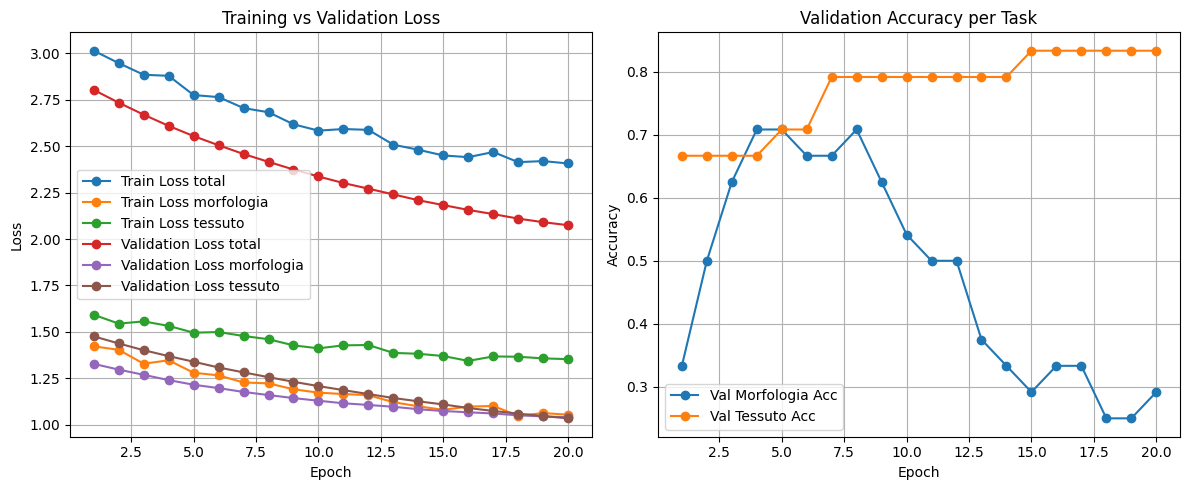

In [32]:
epochs = range(1, n_epochs+1)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses[:, 0], label="Train Loss total", marker="o")
plt.plot(epochs, train_losses[:, 1], label="Train Loss morfologia", marker="o")
plt.plot(epochs, train_losses[:, 2], label="Train Loss tessuto", marker="o")
plt.plot(epochs, val_losses[:, 0], label="Validation Loss total", marker="o")
plt.plot(epochs, val_losses[:, 1], label="Validation Loss morfologia", marker="o")
plt.plot(epochs, val_losses[:, 2], label="Validation Loss tessuto", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

# Accuracy (solo eval)
plt.subplot(1,2,2)
plt.plot(epochs, val_acc_morf, label="Val Morfologia Acc", marker="o")
plt.plot(epochs, val_acc_tess, label="Val Tessuto Acc", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy per Task")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Training with Trainer API

In [33]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    morf_logits, tess_logits = logits["logits_morfologia"], logits["logits_tessuto_adiposo"]
    morf_labels, tess_labels = labels["labels_morfologia"], labels["labels_tessuto_adiposo"]

    morf_preds = morf_logits.argmax(axis=-1)
    tess_preds = tess_logits.argmax(axis=-1)

    return {
        "accuracy_morfologia": accuracy_score(morf_labels, morf_preds),
        "accuracy_tessuto": accuracy_score(tess_labels, tess_preds),
    }

In [34]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'input_ids', 'attention_mask', 'labels_morfologia', 'labels_tessuto'],
        num_rows: 112
    })
    validation: Dataset({
        features: ['text', 'input_ids', 'attention_mask', 'labels_morfologia', 'labels_tessuto'],
        num_rows: 24
    })
})